## Notebook to inspect FL model weights 

In [46]:
import torch.nn as nn
import numpy as np
import pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
import glob 
from pathlib import Path
from shared import SimpleNet, eval_local, train_local, get_initial_arrays
import matplotlib.pyplot as plt

In [47]:
# create subplots for a given layer across rounds
def plot_layer_weights_across_rounds(layer_name, npz_files):
    num_rounds = len(npz_files)
    fig, axes = plt.subplots(1, num_rounds, figsize=(20, 3))

    for i, npz_file in enumerate(npz_files):
        print(f"Inspecting {npz_file}")
        arrays = np.load(npz_file, allow_pickle=True)
        if layer_name in arrays.files:
            weights = arrays[layer_name]
            if num_rounds == 1:
                axes.imshow(weights, cmap='coolwarm')
                axes.set_title(f'{Path(npz_file).name}')
            else:
                axes[i].imshow(weights, cmap='coolwarm')
                axes[i].set_title(f'{Path(npz_file).name}')

            # set colorbar
            if num_rounds == 1:
                plt.colorbar(axes.imshow(weights, cmap='coolwarm'), ax=axes)
            else:
                plt.colorbar(axes[i].imshow(weights, cmap='coolwarm'), ax=axes[i])

        else:
            print(f"Layer {layer_name} not found in {npz_file}")
        
    plt.show()

In [42]:
checkpoint_dir = "./checkpoints"

# read npz files
npz_files = glob.glob(f"{checkpoint_dir}/*.npz")

print(f"Found {len(npz_files)} npz files in {checkpoint_dir}")

# find out names and shapes of layers
layer_names = np.load(npz_files[0], allow_pickle=True).files
array_shapes = {layer_name: np.load(npz_files[0], allow_pickle=True)[layer_name].shape for layer_name in layer_names}
print(f"Array shapes: {array_shapes}")

Found 4 npz files in ./checkpoints
Array shapes: {'arr_0': (64, 134), 'arr_1': (64,), 'arr_2': (2, 64), 'arr_3': (2,)}


Inspecting ./checkpoints/round_1_weights.npz
Inspecting ./checkpoints/final_model.npz


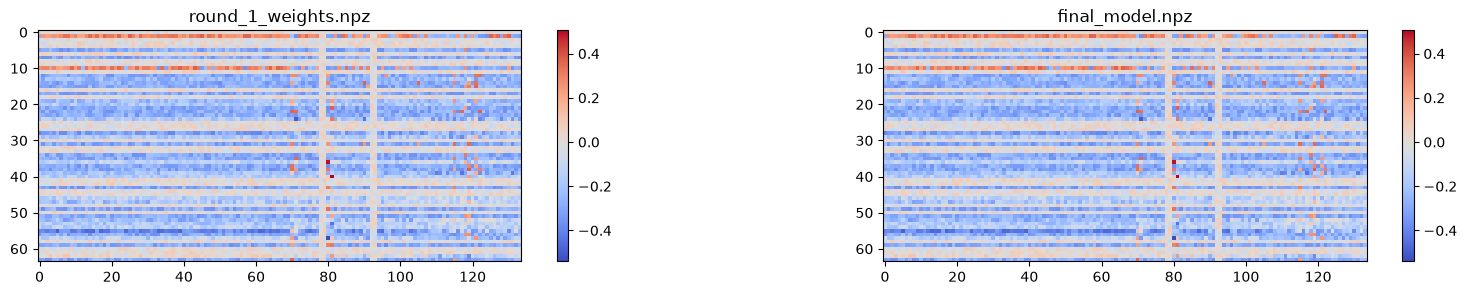

In [48]:
# Plot the weights of the first layer of the model
plot_npz_files = [
    './checkpoints/round_1_weights.npz', #npz_files
    './checkpoints/final_model.npz'
]
    
layer_name = "arr_0"

plot_layer_weights_across_rounds(layer_name, plot_npz_files)

In [ ]:
# Plot difference between weights of the first layer of the model across rounds

